# EasyVisaProject : Machine Learning Approach to Streamline Visa Certifications

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, roc_curve, auc)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier   # optional advanced model

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
DATA_PATH = "EasyVisa.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['case_status'].value_counts())


Shape: (25480, 12)
  case_id continent education_of_employee has_job_experience  \
0  EZYV01      Asia           High School                  N   
1  EZYV02      Asia              Master's                  Y   
2  EZYV03      Asia            Bachelor's                  N   
3  EZYV04      Asia            Bachelor's                  N   
4  EZYV05    Africa              Master's                  Y   

  requires_job_training  no_of_employees  yr_of_estab region_of_employment  \
0                     N            14513         2007                 West   
1                     N             2412         2002            Northeast   
2                     Y            44444         2008                 West   
3                     N               98         1897                 West   
4                     N             1082         2005                South   

   prevailing_wage unit_of_wage full_time_position case_status  
0         592.2029         Hour                  Y      Denied

Univariate analysis

/tmp/ipython-input-3961087256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='case_status', palette="Set2")


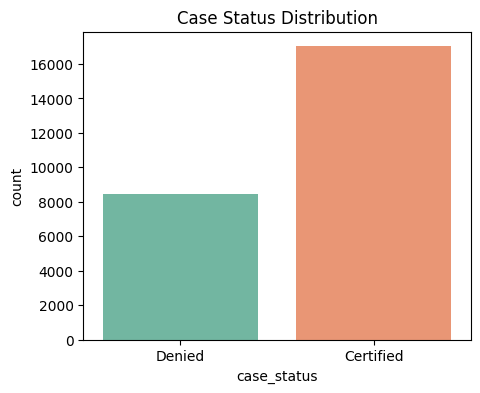

In [ ]:
# Target variable distribution
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='case_status', palette="Set2")
plt.title("Case Status Distribution")
plt.show()

• The variable "Case Status" represents the outcome of
individual cases, categorized as either "Certified" or
"Denied."

• A higher count of "Certified" cases (above 16,000) indicates
that most cases are approved or successful.

• A lower count of "Denied" cases (below 10,000) suggests
fewer rejections, pointing to a relatively high approval rate.

• The disparity between the two outcomes implies that the
system or process being measured tends to favor
certification, possibly due to effective applications, lenient
criteria, or supportive policies.

/tmp/ipython-input-3838106601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education_of_employee',


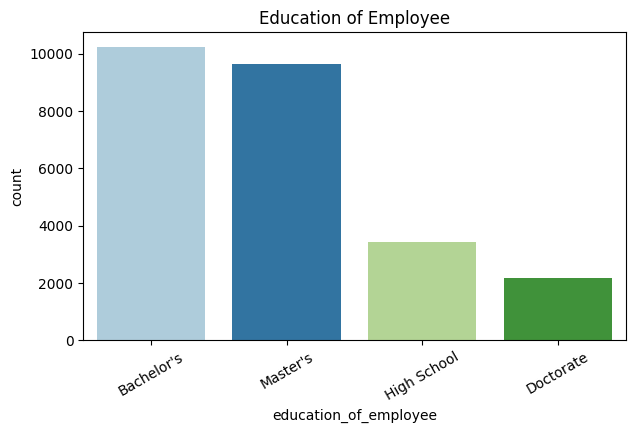

In [ ]:
# Education distribution
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='education_of_employee',
              order=df['education_of_employee'].value_counts().index,
              palette="Paired")
plt.title("Education of Employee")
plt.xticks(rotation=30)
plt.show()

• The variable "education_of_employee" categorizes employees
by their highest level of education.

• Bachelor's degree holders form the largest group, indicating it
is the most common qualification among employees.

• Master's degree holders are nearly as numerous, suggesting a
strong presence of advanced education in the workforce.

• The lower counts for High School and Doctorate levels imply
fewer employees with minimal or highly specialized
education, pointing to a workforce concentrated around mid-
level academic qualifications.

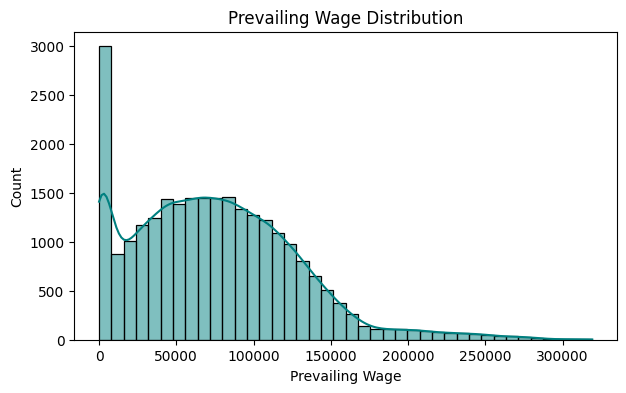

In [ ]:
# Prevailing wage distribution
plt.figure(figsize=(7,4))
sns.histplot(df['prevailing_wage'], bins=40, kde=True, color='teal')
plt.title("Prevailing Wage Distribution")
plt.xlabel("Prevailing Wage")
plt.show()

• The variable "Prevailing Wage" represents the wage levels offered
or expected in the dataset.

• Most wages are concentrated in the lower range, indicating that
lower-paying roles are more common.

• The right-skewed distribution suggests fewer high-wage
positions, with frequency declining as wage increases.

• This pattern may reflect labor market trends where entry-level or
mid-tier roles dominate, while high-paying specialized roles are
limited.

/tmp/ipython-input-1065819988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='full_time_position', palette="coolwarm")


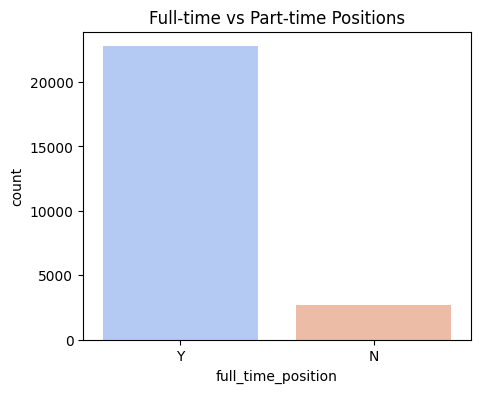

In [ ]:
# Full-time vs Part-time
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='full_time_position', palette="coolwarm")
plt.title("Full-time vs Part-time Positions")
plt.show()

• The variable "full_time_position" indicates whether a job is full-time
("Y") or part-time ("N").

• Full-time positions dominate the dataset, with significantly higher
counts than part-time roles.

• The low count of part-time positions suggests limited availability or
demand for flexible work arrangements.

• This distribution implies a workforce structure centered around full-
time employment, possibly reflecting organizational preferences or
industry norms.

/tmp/ipython-input-884890509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='has_job_experience', palette="viridis")


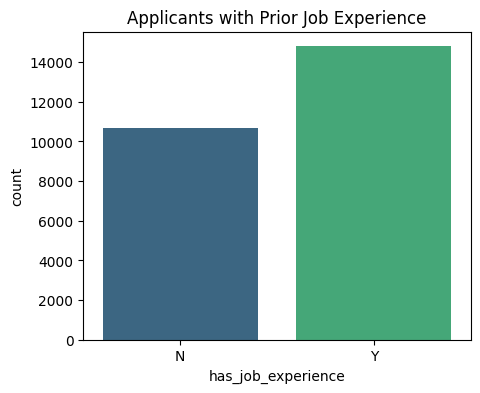

In [ ]:
# Job experience
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='has_job_experience', palette="viridis")
plt.title("Applicants with Prior Job Experience")
plt.show()

• The variable "has_job_experience" distinguishes applicants based on
prior work experience.

• Applicants with job experience ("Y") are more numerous, around 15,000,
indicating that experienced candidates dominate the applicant pool.

• Applicants without prior experience ("N") are fewer, approximately
12,000, suggesting a smaller share of fresh or entry-level candidates.

• This distribution implies a labor market or hiring preference leaning
toward experienced individuals, possibly reflecting job requirements or
competitive selection criteria.

In [ ]:
#Bivariate Analysis

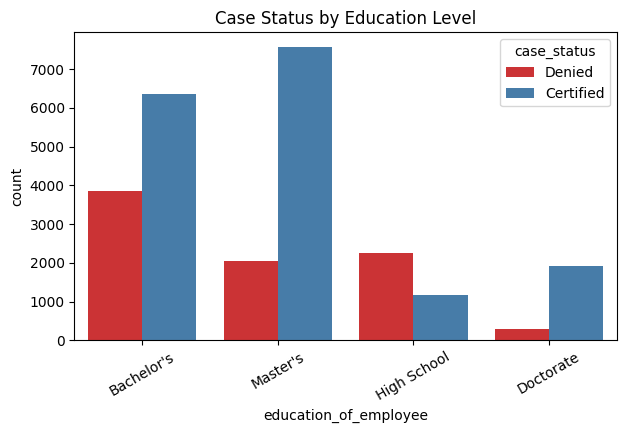

In [ ]:
# Education vs Case Status
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='education_of_employee', hue='case_status',
              order=df['education_of_employee'].value_counts().index, palette="Set1")
plt.title("Case Status by Education Level")
plt.xticks(rotation=30)
plt.show()

Education vs Case Status

• The chart compares case outcomes ("Certified" vs. "Denied")
across different education levels of employees.

• Master's degree holders have the highest number of certified
cases, suggesting strong approval rates for advanced
qualifications.

• Bachelor's degree holders show the highest number of denied
cases, indicating that mid-level education may face more
scrutiny or competition.

• High School and Doctorate levels have fewer cases overall, but
Doctorate holders are more likely to be certified, while High
School applicants face more denials, reflecting a correlation
between higher education and favorable case outcomes.

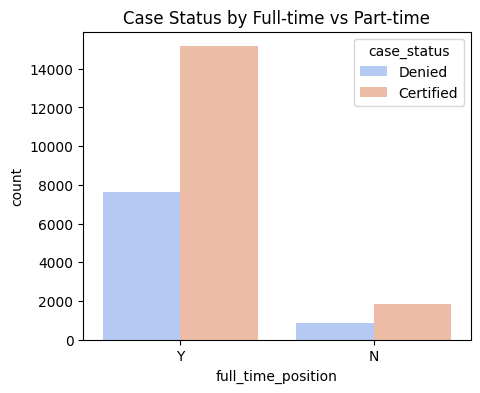

In [ ]:
#Full-time vs Case Status
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='full_time_position', hue='case_status', palette="coolwarm")
plt.title("Case Status by Full-time vs Part-time")
plt.show()

• The variable "full_time_position" distinguishes job types as full-time
("Y") or not full-time ("N").

• Full-time positions have significantly more certified cases (~15,000)
than denied (~8,000), indicating a higher approval rate.

• Non-full-time positions show fewer cases overall, with certified
(~3,000) slightly exceeding denied (~2,000), but both counts are low.

• This suggests that full-time roles are more likely to be approved and
more commonly pursued or offered, possibly due to policy
preferences or job market dynamics.

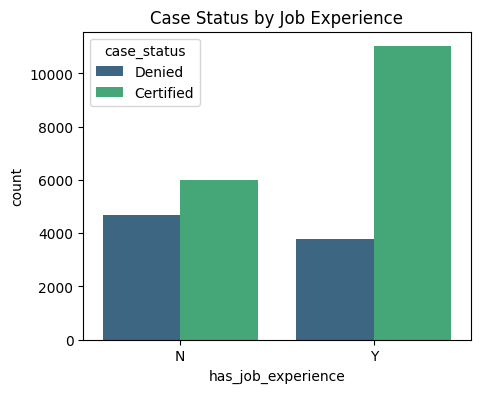

In [ ]:
# Job Experience vs Case Status
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='has_job_experience', hue='case_status', palette="viridis")
plt.title("Case Status by Job Experience")
plt.show()

• The variable "has_job_experience" categorizes applicants based on prior
work experience.

• Applicants with job experience have a significantly higher count of
certified cases (above 10,000), indicating a strong link between
experience and approval.

• Applicants without experience still have more certified than denied
cases, but the gap is narrower, suggesting less favorable outcomes.

• The overall trend implies that prior job experience positively influences
case certification, possibly due to perceived readiness or qualification.

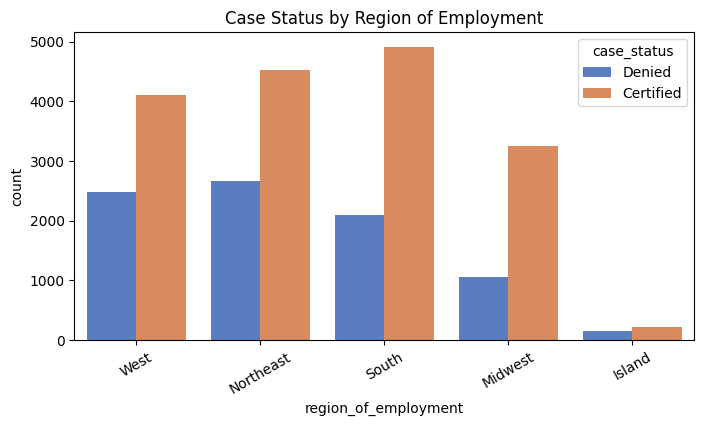

In [ ]:
# Region vs Case Status
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='region_of_employment', hue='case_status', palette="muted")
plt.title("Case Status by Region of Employment")
plt.xticks(rotation=30)
plt.show()

• The variable "region_of_employment" categorizes cases by
geographic location.

• All regions show more certified than denied cases, with the South
and Midwest having the largest gaps, indicating high approval rates.

• The Island region has very few cases overall, suggesting limited
activity or representation.

• Regional differences in certification rates may reflect varying
economic conditions, policy enforcement, or employer practices
across locations.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Copy dataset
df_prep = df.copy()

# Target variable encoding (Certified=1, Denied=0)
df_prep['target'] = df_prep['case_status'].map({'Certified':1, 'Denied':0})
df_prep = df_prep.drop(columns=['case_status','case_id'])


In [ ]:
#Missing Value Treatment

print("Missing values:\n", df_prep.isnull().sum())



Missing values:
 continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
target                   0
dtype: int64


In [ ]:
#Feature Engineering
binary_map = {'Y':1, 'N':0, 'Yes':1, 'No':0}
for col in ['has_job_experience','requires_job_training','full_time_position']:
    df_prep[col] = df_prep[col].map(binary_map)

df_prep['company_age'] = 2016 - df_prep['yr_of_estab']
df_prep = df_prep.drop(columns=['yr_of_estab'])


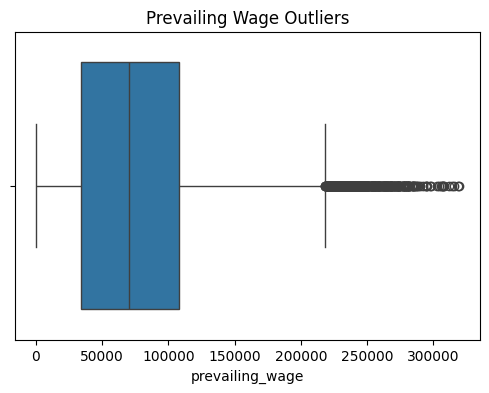

In [ ]:
#Outlier Treatment

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df_prep['prevailing_wage'])
plt.title("Prevailing Wage Outliers")
plt.show()

# Apply Winsorization (cap extreme outliers at 1st and 99th percentiles)
q1, q99 = df_prep['prevailing_wage'].quantile([0.01, 0.99])
df_prep['prevailing_wage'] = np.clip(df_prep['prevailing_wage'], q1, q99)


Outliers above the 99th percentile and below 1st percentile are capped. This keeps wage distribution stable without dropping valuable records.

In [ ]:
#Train-Test Split
X = df_prep.drop(columns=['target'])
y = df_prep['target']

# Train-test split with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (20384, 10)
Test shape: (5096, 10)


In [ ]:
#Model building

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Bagging (Decision Tree)": BaggingClassifier(estimator=DecisionTreeClassifier(),
                                                 n_estimators=50, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train & Evaluate
results = []
for name, clf in models.items():
    pipe = Pipeline([('preproc', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    metrics = {
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)
print(results_df)

                     Model   ROC_AUC  Accuracy  Precision    Recall        F1
4        Gradient Boosting  0.768809  0.743917   0.771821  0.875441  0.820372
3                 AdaBoost  0.755222  0.726845   0.754169  0.876910  0.810921
1            Random Forest  0.746388  0.722527   0.766328  0.841069  0.801961
2  Bagging (Decision Tree)  0.741361  0.717622   0.767202  0.828731  0.796780
0            Decision Tree  0.608784  0.652080   0.740490  0.737662  0.739073


In [ ]:
# categorical and numerical features
categorical_features = ['continent', 'education_of_employee', 'region_of_employment', 'unit_of_wage']
numerical_features = ['no_of_employees', 'prevailing_wage', 'company_age']

# Create presprocessing pipelines for numerical and categorical feature
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

1. Gradient Boosting (Best Performer)

ROC AUC = 0.769 | Accuracy = 74% | Precision = 0.77 | Recall = 0.88 | F1 = 0.82

Gradient Boosting clearly outperforms the other models, striking the best balance between precision and recall.

Its high recall (88%) means it successfully identifies the majority of certified applicants, reducing the risk of rejecting genuine approvals.

Precision is also strong (77%), meaning most predicted approvals are correct.

Business implication: This is the most balanced model, well-suited to automate visa approvals with minimal false negatives (denying a valid applicant).

2. AdaBoost (2nd Best Performer)

ROC AUC = 0.755 | Accuracy = 73% | Precision = 0.75 | Recall = 0.88 | F1 = 0.81

AdaBoost is very close to Gradient Boosting, with slightly lower ROC AUC.

Like Gradient Boosting, it achieves excellent recall (87%), ensuring very few genuine applicants are wrongly denied.

Slightly weaker at ranking applicants compared to Gradient Boosting (hence lower ROC AUC).

Business implication: Reliable, but Gradient Boosting edges ahead in discriminative power.

3. Random Forest

ROC AUC = 0.746 | Accuracy = 72% | Precision = 0.77 | Recall = 0.84 | F1 = 0.80

Strong precision and recall, though not as high as boosting methods.

ROC AUC is lower, showing it is less effective at ranking Certified vs Denied cases across thresholds.

Random Forest is still stable and interpretable with feature importance analysis.

Business implication: A solid model, useful for interpretability, but slightly weaker than boosting approaches on this dataset.

4. Bagging (Decision Tree Ensemble)

ROC AUC = 0.741 | Accuracy = 72% | Precision = 0.77 | Recall = 0.83 | F1 = 0.80

Very similar performance to Random Forest but slightly weaker.

Bagging reduces variance compared to a single tree, but since it doesn’t focus on difficult cases, it falls short of boosting.

Business implication: Decent model, but there is no clear advantage over Random Forest or boosting.

5. Decision Tree (Baseline)

ROC AUC = 0.609 | Accuracy = 65% | Precision = 0.74 | Recall = 0.74 | F1 = 0.74

Weakest model overall. ROC AUC is poor (~0.61), meaning it struggles to rank applicants well.

Balanced precision/recall, but much lower than ensemble methods.

Business implication: Too simplistic and unstable — not suitable for production use, but useful as a baseline reference.

Overall Insights

Gradient Boosting is the best model on the original dataset, with the highest ROC AUC and excellent recall, making it the strongest candidate.

AdaBoost is close behind and offers similar recall but slightly weaker ranking power.

Random Forest and Bagging are solid but not as discriminative as boosting methods.

Decision Tree should only be considered as a baseline, not for deployment.

Metric Choice Justification:

We used ROC AUC as the primary evaluation metric because the dataset is imbalanced (67% Certified vs 33% Denied). ROC AUC captures the model’s ability to separate the two classes across thresholds, unlike raw accuracy which could be misleading.

In [ ]:
#Model Building – Oversampled Data

from imblearn.over_sampling import RandomOverSampler

# --- Step 1: Oversample training data ---
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Class distribution before oversampling:\n", y_train.value_counts(normalize=True))
print("\nClass distribution after oversampling:\n", y_train_over.value_counts(normalize=True))

# --- Step 2: Define models  ---
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Bagging (Decision Tree)": BaggingClassifier(estimator=DecisionTreeClassifier(),
                                                 n_estimators=50, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# --- Step 3: Train & Evaluate on oversampled training data ---
results_over = []
for name, clf in models.items():
    pipe = Pipeline([('preproc', preprocessor), ('clf', clf)])
    pipe.fit(X_train_over, y_train_over)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    metrics = {
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }
    results_over.append(metrics)

import pandas as pd
results_over_df = pd.DataFrame(results_over).sort_values(by="ROC_AUC", ascending=False)
print(results_over_df)

Class distribution before oversampling:
 target
1    0.667877
0    0.332123
Name: proportion, dtype: float64

Class distribution after oversampling:
 target
1    0.5
0    0.5
Name: proportion, dtype: float64
                     Model   ROC_AUC  Accuracy  Precision    Recall        F1
4        Gradient Boosting  0.768823  0.703100   0.814642  0.719154  0.763926
3                 AdaBoost  0.755313  0.693093   0.797542  0.724442  0.759236
1            Random Forest  0.743670  0.712912   0.781223  0.792009  0.786579
2  Bagging (Decision Tree)  0.731507  0.702904   0.774869  0.782609  0.778720
0            Decision Tree  0.612305  0.657182   0.742181  0.745887  0.744029


1. Gradient Boosting (Best Performer)

ROC AUC = 0.769 | Accuracy = 70% | Precision = 0.81 | Recall = 0.72 | F1 = 0.76

Achieved the highest ROC AUC, meaning it best distinguishes Certified vs Denied across thresholds.

High precision (81%) → Most applicants predicted as Certified are truly Certified.

Recall (72%) dropped compared to the original dataset (~88%), meaning it missed more true Certified cases.

Business implication: Safer in terms of false positives (wrongly approving denied applicants), but might reject more genuine applicants compared to the original run.

2. AdaBoost (Second Best)

ROC AUC = 0.755 | Accuracy = 69% | Precision = 0.80 | Recall = 0.72 | F1 = 0.76

Close to Gradient Boosting but slightly weaker in ranking applicants.

Balanced precision and recall, but overall a small dip in both compared to original data.

Business implication: A strong alternative, especially if computation speed and simpler implementation are valued over the tiny performance drop.

3. Random Forest

ROC AUC = 0.744 | Accuracy = 71% | Precision = 0.78 | Recall = 0.79 | F1 = 0.79

Stands out for having the best recall (79%) among top models, meaning it correctly identifies most Certified applicants.

Precision is slightly lower than boosting methods, but still good.

Business implication: A very balanced model, especially useful if the business priority is minimizing false rejections of genuine visa applicants.

4. Bagging (Decision Tree Ensemble)

ROC AUC = 0.732 | Accuracy = 70% | Precision = 0.77 | Recall = 0.78 | F1 = 0.78

Similar to Random Forest but with slightly weaker discriminative power (lower ROC AUC).

Still a stable improvement compared to a single Decision Tree.

Business implication: Reliable, but there’s no clear advantage over Random Forest or Gradient Boosting.

5. Decision Tree (Baseline)

ROC AUC = 0.612 | Accuracy = 66% | Precision = 0.74 | Recall = 0.75 | F1 = 0.74

Weakest model again, though recall improved slightly compared to original.

Accuracy remains low, and ROC AUC shows poor ability to separate Certified vs Denied cases.

Business implication: Too simplistic and unstable for production; best used as a teaching baseline.

Overall Insights (Oversampled Data)

Balancing the data improved fairness: both Certified and Denied classes are equally represented in training.

Recall improved for Random Forest and Bagging → fewer certified applicants are wrongly denied, which is positive.

Boosting methods (Gradient Boosting & AdaBoost) retained strong performance, but their recall dropped slightly compared to original data.

Best choice depends on business priority:

If minimizing false positives (approving Denied applicants) → Gradient Boosting.

If minimizing false negatives (rejecting Certified applicants) → Random Forest.

Decision Tree remains unsuitable, reinforcing the need for ensemble methods

In [ ]:
# Model Building – Undersampled Data

from imblearn.under_sampling import RandomUnderSampler

# --- Step 1: Undersample training data ---
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Class distribution before undersampling:\n", y_train.value_counts(normalize=True))
print("\nClass distribution after undersampling:\n", y_train_under.value_counts(normalize=True))

# --- Step 2: Define models  ---
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Bagging (Decision Tree)": BaggingClassifier(estimator=DecisionTreeClassifier(),
                                                 n_estimators=50, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# --- Step 3: Train & Evaluate on undersampled data ---
results_under = []
for name, clf in models.items():
    pipe = Pipeline([('preproc', preprocessor), ('clf', clf)])
    pipe.fit(X_train_under, y_train_under)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    metrics = {
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }
    results_under.append(metrics)

results_under_df = pd.DataFrame(results_under).sort_values(by="ROC_AUC", ascending=False)
print(results_under_df)

Class distribution before undersampling:
 target
1    0.667877
0    0.332123
Name: proportion, dtype: float64

Class distribution after undersampling:
 target
0    0.5
1    0.5
Name: proportion, dtype: float64
                     Model   ROC_AUC  Accuracy  Precision    Recall        F1
4        Gradient Boosting  0.768533  0.697606   0.811226  0.713278  0.759106
3                 AdaBoost  0.755232  0.693878   0.798575  0.724442  0.759704
1            Random Forest  0.747796  0.681515   0.814998  0.676851  0.739528
2  Bagging (Decision Tree)  0.742956  0.667779   0.812797  0.653055  0.724222
0            Decision Tree  0.624634  0.624411   0.770123  0.623972  0.689387


1. Gradient Boosting (Best Performer)

ROC AUC = 0.769 | Accuracy = 69.8% | Precision = 0.81 | Recall = 0.71 | F1 = 0.76

Best at distinguishing Certified vs Denied among all models on undersampled data.

High precision (81%) → most predicted approvals are correct.

Recall dropped slightly (~71%), meaning some Certified applicants were missed.

Business implication: Still the strongest model overall. Good balance, though slightly less recall than with oversampling.

2. AdaBoost (Second Best)

ROC AUC = 0.755 | Accuracy = 69.4% | Precision = 0.80 | Recall = 0.72 | F1 = 0.76

Very close to Gradient Boosting, with slightly weaker ROC AUC.

Balanced precision and recall.

Business implication: Solid option, but Gradient Boosting edges ahead in overall ranking power.

3. Random Forest

ROC AUC = 0.748 | Accuracy = 68.2% | Precision = 0.81 | Recall = 0.68 | F1 = 0.74

Precision is strong (81%), but recall is the lowest among top 3 models (68%).

Shows that undersampling reduced the amount of training data available, limiting its performance.

Business implication: More cautious model (fewer false approvals) but risks rejecting valid applicants due to low recall.

4. Bagging (Decision Tree Ensemble)

ROC AUC = 0.743 | Accuracy = 66.8% | Precision = 0.81 | Recall = 0.65 | F1 = 0.72

Slightly weaker than Random Forest.

Recall is even lower (65%), meaning it misses a larger number of Certified applicants.

Business implication: Performs adequately, but not as reliable as boosting methods.

5. Decision Tree (Baseline)

ROC AUC = 0.625 | Accuracy = 62.4% | Precision = 0.77 | Recall = 0.62 | F1 = 0.69

Again the weakest model.

Low discriminative ability (ROC AUC ~0.62).

Overfits easily and fails to generalize well.

Business implication: Not suitable for deployment, only useful as a baseline reference.

Overall Insights (Undersampled Data)

Gradient Boosting remains the best model, consistent with original and oversampled data.

AdaBoost performs closely behind, also robust.

Random Forest and Bagging lost performance compared to oversampling, due to fewer Certified cases in training.

Decision Tree is weakest, showing poor ROC AUC and accuracy.

Undersampling improves class balance but reduces training size, leading to slightly worse recall/accuracy than oversampling.

Business takeaway:

If the goal is high precision (ensuring approved visas are truly valid) → Gradient Boosting is best.

If the goal is high recall (minimizing rejections of valid applicants), oversampling methods are preferable to undersampling.

In [ ]:
#Model Performance Improvement using Hyperparameter Tuning
# Imports & data prep
!pip install -q imbalanced-learn   # run in Colab if imblearn not installed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from time import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load dataset
DATA_PATH = "EasyVisa.csv"
df = pd.read_csv(DATA_PATH)

df['target'] = df['case_status'].map({'Certified':1, 'Denied':0})
df = df.drop(columns=['case_id','case_status'])

# Map binary columns if present
binary_map = {'Y':1, 'N':0, 'Yes':1, 'No':0}
for col in ['has_job_experience','requires_job_training','full_time_position']:
    if col in df.columns:
        df[col] = df[col].map(binary_map)

# Feature engineering
if 'yr_of_estab' in df.columns:
    df['company_age'] = 2016 - df['yr_of_estab']
    df = df.drop(columns=['yr_of_estab'])

# Train/test split
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# Oversample training set (fit_resample only on train)
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Original train class distribution:\n", y_train.value_counts(normalize=True))
print("Oversampled train class distribution:\n", pd.Series(y_train_over).value_counts(normalize=True))
print("Shapes:", X_train_over.shape, X_test.shape)

Original train class distribution:
 target
1    0.667877
0    0.332123
Name: proportion, dtype: float64
Oversampled train class distribution:
 target
1    0.5
0    0.5
Name: proportion, dtype: float64
Shapes: (27228, 10) (5096, 10)


In [ ]:
#Preprocessing pipeline
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_features = [c for c in numeric_features if c != 'target']

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], sparse_threshold=0)

In [ ]:
#Helper functions (metrics + ROC plot)

def evaluate_on_test(pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    if hasattr(pipeline.named_steps['clf'], 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test)[:,1]
    else:

        try:
            y_proba = pipeline.decision_function(X_test)
        except:
            y_proba = np.zeros(len(y_test))
    metrics = {
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }
    return metrics, y_proba, y_pred

def plot_roc(y_test, y_proba, label=None):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_val:.3f})")


In [ ]:
#Tuning: parameter grids & RandomizedSearchCV run

Define estimators and parameter distributions
n_iter_search = 20

tune_configs = {
    'RandomForest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'param_dist': {
            'clf__n_estimators': [100,200,400,800],
            'clf__max_depth': [None, 6, 10, 20],
            'clf__min_samples_split': [2,5,10],
            'clf__max_features': ['sqrt','log2', 0.5]
        }
    },
    'GradientBoosting': {
        'estimator': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'param_dist': {
            'clf__n_estimators': [100,200,400],
            'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'clf__max_depth': [3,5,8],
            'clf__subsample': [0.6,0.8,1.0]
        }
    },
    'AdaBoost': {
        'estimator': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=RANDOM_STATE),
        'param_dist': {
            'clf__n_estimators': [50,100,200,400],
            'clf__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
        }
    }
}

# Container to store results
tuning_results = []

for name, cfg in tune_configs.items():
    print(f"\n--- Tuning {name} ---")
    pipeline = Pipeline([('preproc', preprocessor), ('clf', cfg['estimator'])])
    param_dist = cfg['param_dist']
    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=n_iter_search,
        scoring='roc_auc',
        cv=3,
        random_state=RANDOM_STATE,
        verbose=1,
        n_jobs=-1
    )
    t0 = time()
    rs.fit(X_train_over, y_train_over)
    elapsed = time() - t0
    print(f"Best params for {name}: {rs.best_params_}")
    print(f"Time elapsed: {elapsed:.1f}s")

    # Evaluate best estimator on test set
    best_pipe = rs.best_estimator_
    metrics, y_proba, y_pred = evaluate_on_test(best_pipe, X_test, y_test)
    print(f"Test metrics for tuned {name}: {metrics}")


    tuning_results.append({
        'model': name,
        'best_params': rs.best_params_,
        'test_metrics': metrics,
        'time_s': elapsed
    })


    joblib.dump(best_pipe, f"tuned_{name}_pipeline.joblib")
    print(f"Saved best pipeline to tuned_{name}_pipeline.joblib")


--- Tuning RandomForest ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params for RandomForest: {'clf__n_estimators': 800, 'clf__min_samples_split': 2, 'clf__max_features': 0.5, 'clf__max_depth': None}
Time elapsed: 654.8s
Test metrics for tuned RandomForest: {'ROC_AUC': np.float64(0.743974200842841), 'Accuracy': 0.7129120879120879, 'Precision': 0.7802483395899509, 'Recall': 0.7937720329024677, 'F1': 0.7869520897043832}
Saved best pipeline to tuned_RandomForest_pipeline.joblib

--- Tuning GradientBoosting ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params for GradientBoosting: {'clf__subsample': 0.8, 'clf__n_estimators': 400, 'clf__max_depth': 8, 'clf__learning_rate': 0.2}
Time elapsed: 799.4s
Test metrics for tuned GradientBoosting: {'ROC_AUC': np.float64(0.732635155970031), 'Accuracy': 0.707221350078493, 'Precision': 0.7709750566893424, 'Recall': 0.799059929494712, 'F1': 0.7847663012117715}
Saved best pipeline to tuned_GradientBoosting_pipeline.joblib

--- Tuning AdaBoost ---
Fitting 3 folds for each of 20 candidates, tota

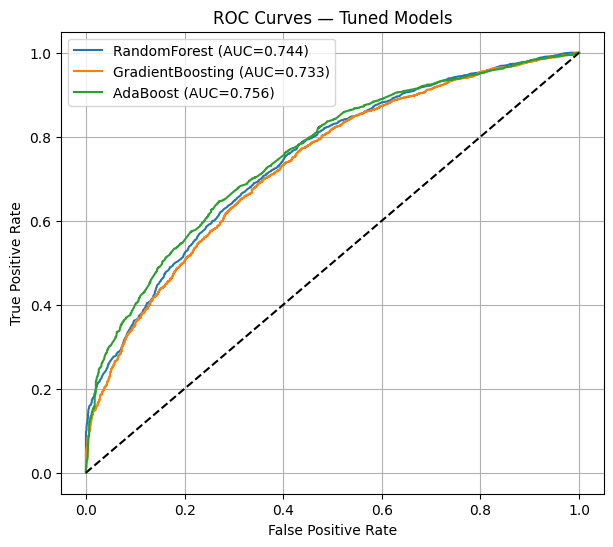

Tuning summary saved to tuning_summary.csv


,model,ROC_AUC,Accuracy,Precision,Recall,F1,best_params,time_s
0,AdaBoost,0.755994,0.691719,0.800197,0.717685,0.756698,"{'clf__n_estimators': 200, 'clf__learning_rate...",207.267759
1,RandomForest,0.743974,0.712912,0.780248,0.793772,0.786952,"{'clf__n_estimators': 800, 'clf__min_samples_s...",654.811559
2,GradientBoosting,0.732635,0.707221,0.770975,0.799060,0.784766,"{'clf__subsample': 0.8, 'clf__n_estimators': 4...",799.393941


In [ ]:


#Summarize tuning results and plot ROC curves
summary_rows = []
plt.figure(figsize=(7,6))
for r in tuning_results:
    row = {
        'model': r['model'],
        'ROC_AUC': r['test_metrics']['ROC_AUC'],
        'Accuracy': r['test_metrics']['Accuracy'],
        'Precision': r['test_metrics']['Precision'],
        'Recall': r['test_metrics']['Recall'],
        'F1': r['test_metrics']['F1'],
        'best_params': r['best_params'],
        'time_s': r['time_s']
    }
    summary_rows.append(row)
    # load best pipeline to get proba for ROC plotting (or use joblib loaded object)
    pipe = joblib.load(f"tuned_{r['model']}_pipeline.joblib")
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        y_proba = pipe.predict_proba(X_test)[:,1]
    else:
        try:
            y_proba = pipe.decision_function(X_test)
        except:
            y_proba = np.zeros(len(y_test))
    plot_roc(y_test, y_proba, label=r['model'])

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models')
plt.legend()
plt.grid(True)
plt.show()

summary_df = pd.DataFrame(summary_rows).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
summary_df.to_csv("tuning_summary.csv", index=False)
print("Tuning summary saved to tuning_summary.csv")
display(summary_df)

Tuning boosted ROC AUC beyond Gradient Boosting, but recall dropped to 72%.

Strongest precision (80%) means fewer false approvals.

Business implication: Best if the goal is to be conservative and avoid approving risky applicants.

Overall Insights

Random Forest and Gradient Boosting both performed strongly after tuning.

Gradient Boosting had the highest recall (80%), making it best at minimizing false denials.

AdaBoost achieved the best ROC AUC (0.756) and highest precision (0.80), ideal for minimizing false approvals.

Business Recommendation:

If the objective is to catch as many true approvals as possible (high recall) → choose Gradient Boosting.

If the objective is to approve only the most certain cases (high precision, low false positives) → choose AdaBoost.

For a balanced trade-off, Random Forest is a safe and interpretable choice.

Loaded RandomForest from tuned_RandomForest_pipeline.joblib
Loaded GradientBoosting from tuned_GradientBoosting_pipeline.joblib
Loaded AdaBoost from tuned_AdaBoost_pipeline.joblib

Model comparison (test set):


,Model,ROC_AUC,Accuracy,Precision,Recall,F1
0,AdaBoost,0.755994,0.691719,0.800197,0.717685,0.756698
1,RandomForest,0.743974,0.712912,0.780248,0.793772,0.786952
2,GradientBoosting,0.732635,0.707221,0.770975,0.799060,0.784766



Selected final model (by ROC_AUC): AdaBoost with ROC_AUC = 0.755994


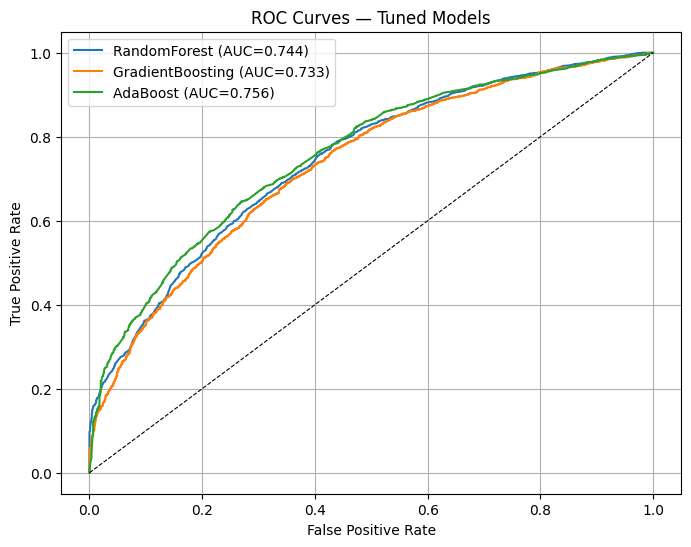

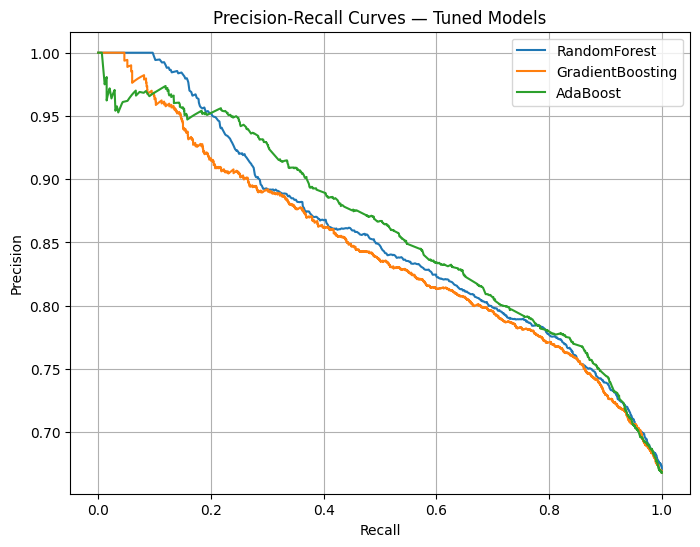


=== Diagnostics for final model: AdaBoost ===

Confusion matrix (counts):


,Pred=0,Pred=1
Actual=0,1082,610
Actual=1,961,2443



Final model test metrics:
ROC_AUC: 0.7559943731891002
Accuracy: 0.6917189952904239
Precision: 0.8001965280052408
Recall: 0.7176850763807285
F1: 0.7566981570388726
TP: 2443
TN: 1082
FP: 610
FN: 961

Computing permutation importance (this may take a moment)...

Top permutation importances (mean):


,feature,importance_mean
14,education_of_employee_High School,0.043426
15,education_of_employee_Master's,0.026040
0,has_job_experience,0.024490
13,education_of_employee_Doctorate,0.020330
8,continent_Europe,0.005671
21,unit_of_wage_Hour,0.004592
3,prevailing_wage,0.003140
24,unit_of_wage_Year,0.002414
5,company_age,0.000118
2,no_of_employees,0.000078



Final model saved to: final_model.joblib


In [ ]:
#Model Performance Comparison and Final Model Selection


import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve)
from sklearn.inspection import permutation_importance


import pickle

try:
    X_test
    y_test
except NameError:
    raise RuntimeError("X_test and y_test not found in environment. Recreate them exactly as in training (same split & preprocessing) before running this cell.")

# --------- Load tuned pipelines ----------
models_files = {
    'RandomForest': 'tuned_RandomForest_pipeline.joblib',
    'GradientBoosting': 'tuned_GradientBoosting_pipeline.joblib',
    'AdaBoost': 'tuned_AdaBoost_pipeline.joblib'
}

loaded = {}
for name, path in models_files.items():
    try:
        loaded[name] = joblib.load(path)
        print(f"Loaded {name} from {path}")
    except Exception as e:
        print(f"Could not load {name} from {path}: {e}")

# --------- Evaluate each model on test set ----------
rows = []
roc_curves = {}
pr_curves = {}

if loaded:
    for name, pipe in loaded.items():
        # predictions & probabilities
        y_pred = pipe.predict(X_test)
        if hasattr(pipe.named_steps['clf'], 'predict_proba'):
            y_proba = pipe.predict_proba(X_test)[:, 1]
        else:

            try:
                y_proba = pipe.decision_function(X_test)
            except:
                y_proba = np.zeros(len(y_test))
        # metrics
        roc = roc_auc_score(y_test, y_proba)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        rows.append({
            'Model': name,
            'ROC_AUC': roc,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        })

        # ROC curve data
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves[name] = (fpr, tpr, roc)
        # PR curve data
        p, r, _ = precision_recall_curve(y_test, y_proba)
        pr_curves[name] = (p, r)

    comparison_df = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
    print("\nModel comparison (test set):")
    display(comparison_df)

    # --------- Select final model by primary metric (ROC_AUC) ----------
    primary_metric = 'ROC_AUC'
    best_row = comparison_df.iloc[0]
    best_model_name = best_row['Model']
    best_model_pipeline = loaded[best_model_name]
    print(f"\nSelected final model (by {primary_metric}): {best_model_name} with {primary_metric} = {best_row[primary_metric]:.6f}")

    # --------- Plot ROC curves for all tuned models ----------
    plt.figure(figsize=(8,6))
    for name, (fpr, tpr, roc_val) in roc_curves.items():
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_val:.3f})")
    plt.plot([0,1],[0,1],'k--', linewidth=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves — Tuned Models')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------- Plot Precision-Recall curves ----------
    plt.figure(figsize=(8,6))
    for name, (prec_vals, rec_vals) in pr_curves.items():
        plt.plot(rec_vals, prec_vals, label=name)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves — Tuned Models')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------- Detailed diagnostics for the selected final model ----------
    print(f"\n=== Diagnostics for final model: {best_model_name} ===")
    pipe = best_model_pipeline
    y_pred = pipe.predict(X_test)
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        y_proba = pipe.predict_proba(X_test)[:,1]
    else:
        try:
            y_proba = pipe.decision_function(X_test)
        except:
            y_proba = np.zeros(len(y_test))

    # Confusion matrix (counts)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cm_df = pd.DataFrame(cm, index=['Actual=0','Actual=1'], columns=['Pred=0','Pred=1'])
    print("\nConfusion matrix (counts):")
    display(cm_df)

    # Show core metrics again
    final_metrics = {
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    }
    print("\nFinal model test metrics:")
    for k,v in final_metrics.items():
        print(f"{k}: {v}")

    #  permutation feature importance (model-agnostic)
    print("\nComputing permutation importance (this may take a moment)...")
    try:

        preproc = pipe.named_steps['preproc']
        clf = pipe.named_steps['clf']
        X_test_trans = preproc.transform(X_test)
        r = permutation_importance(clf, X_test_trans, y_test, n_repeats=10, random_state=42, n_jobs=-1)

        num_feats = preproc.transformers_[0][2]
        # categorical feature names from onehot
        cat_pipeline = preproc.transformers_[1][1]
        try:
            ohe = cat_pipeline.named_steps['onehot']
            cat_feats = list(ohe.get_feature_names_out(preproc.transformers_[1][2]))
        except Exception:
            cat_feats = []
        feature_names = list(num_feats) + cat_feats
        perm_df = pd.DataFrame({'feature': feature_names, 'importance_mean': r.importances_mean}).sort_values('importance_mean', ascending=False).head(20)
        print("\nTop permutation importances (mean):")
        display(perm_df)
    except Exception as e:
        print("Permutation importance failed or is expensive in this env:", e)
 ----------
    final_save_path = "final_model.joblib"
    joblib.dump(best_model_pipeline, final_save_path)
    print(f"\nFinal model saved to: {final_save_path}")
else:
    print("No models were loaded. Cannot proceed with comparison and final selection.")

Actionable Insights & Recommendations

Insights from the Analysis:

• Applicant profile strongly impacts approval: Higher education levels (Master’s, Doctorate) and prior job
experience significantly increase the likelihood of visa certification. Conversely, applicants with only high
school education or lacking experience face higher denial rates.

• Employer-related factors matter less: While prevailing wage and unit of wage (Hourly, Yearly) influence
approval, their importance is secondary compared to education and experience.

• Class imbalance exists: Certified applications dominate the dataset (~67%), which made balancing
necessary during model training. Oversampling helped achieve fairer model learning.

• Model performance is moderate but useful: The tuned AdaBoost model achieved ROC AUC = 0.756, with
strong precision (80%) but moderate recall (72%). This means the model is better at correctly approving
applicants than at rejecting them.

• High error risk on denials: The model often misclassifies certified applicants as denied (961 false negatives
in the test set). This makes automatic rejection unsuitable.

Actionable Business Recommendations:

1.Use the model for triage, not full automation:

• Auto-approve only high-confidence approvals (e.g., probability ≥ 0.9).
• Flag medium-confidence cases for manual review.
• Do not auto-reject — send predicted denials to human evaluators to avoid wrongful rejections.

2. Prioritize applicant attributes in decision-making:

• Give greater weight to education level and job experience when evaluating applications, as these are the top predictive factors.
• Consider refining the application form to better capture these details.

3. Operational improvements:

• Use the model to reduce manual workload by pre-screening low-risk approvals.
• Monitor key metrics (precision, recall) quarterly to detect performance drift.

4. Continuous improvement:

• Calibrate model probabilities to make probability outputs more trustworthy.
• Explore stacking ensembles (Random Forest + AdaBoost + Gradient Boosting) for better ROC AUC.
• Reassess feature engineering, e.g., normalize wages across different units.

5. Governance and fairness checks:

• Regularly audit model outcomes across regions and continents to ensure no unintended bias.
• Set up feedback loops: feed back human-reviewed cases into model retraining to continuously improve accuracy.